# Predictive Maintenance Using Machine Learning

**Machine Learning Project**

This project uses machine learning to predict whether a machine is likely to fail based on its operating conditions.

The dataset contains information such as air temperature, process temperature, rotational speed, torque, and tool wear. A machine learning classification model is trained to identify cases where a failure occurs.

The project also includes data visualization, model evaluation, confusion matrix analysis, and feature importance to understand the model's results.


## 1. Project Objective

The objective of this project is to build a machine learning model that can predict machine failure from sensor and operating data.

Instead of waiting for a machine to fail, predictive maintenance uses available condition data to identify possible failures earlier. This can help reduce unexpected downtime and support better maintenance planning.

The project follows a complete machine learning workflow from data loading and exploration to preprocessing, model training, evaluation, and prediction.


## 2. Dataset

The **AI4I 2020 Predictive Maintenance Dataset** is used for this project. It contains synthetic industrial machine data representing different operating conditions and machine failures.

The target variable is **Machine failure**, which indicates whether a failure occurred for a particular observation.


In [7]:
import os
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", None)


In [8]:
# Download and load the UCI Predictive Maintenance dataset

import os
import requests
import zipfile
import pandas as pd

url = "https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip"

zip_path = "/content/ai4i_dataset.zip"
extract_path = "/content/ai4i_dataset"

# Download the dataset
if not os.path.exists(zip_path):
    response = requests.get(url, timeout=60)
    response.raise_for_status()

    with open(zip_path, "wb") as f:
        f.write(response.content)

# Extract the dataset
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

# Find the dataset file
data_file = None

for root, _, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".csv", ".xlsx")):
            data_file = os.path.join(root, file)
            break
    if data_file:
        break

if data_file is None:
    raise FileNotFoundError("The dataset CSV/Excel file was not found.")

# Load the dataset
if data_file.lower().endswith(".csv"):
    df = pd.read_csv(data_file)
else:
    df = pd.read_excel(data_file)

print("Dataset loaded successfully.")
print("File:", data_file)
print("Shape:", df.shape)

display(df.head())


Dataset loaded successfully.
File: /content/ai4i_dataset/ai4i2020.csv
Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Initial Data Inspection

Before starting the analysis, the dataset is checked to understand its size, columns, data types, missing values, and duplicate records.


In [9]:
print("First five rows:")
display(df.head())

print("\nDataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


First five rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0



Duplicate rows: 0


## 4. Basic Dataset Information

The dataset contains machine operating measurements along with the target failure indicator. The numerical columns describe the condition of the machine at each observation.


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDescriptive statistics:")
display(df.describe())


Number of rows: 10000
Number of columns: 14

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Descriptive statistics:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 5. Understanding Machine Failure

The target variable is **Machine failure**.

A value of 0 represents normal operation, while a value of 1 represents a machine failure. The distribution is visualized below to see how common failure cases are in the dataset.


Machine failure
0    9661
1     339
Name: count, dtype: int64


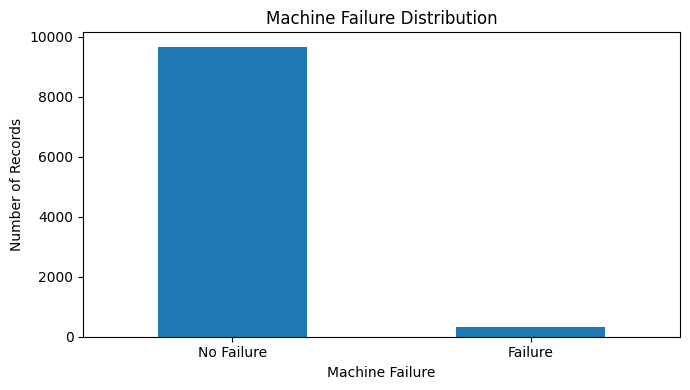

In [11]:
failure_counts = df["Machine failure"].value_counts().sort_index()

print(failure_counts)

plt.figure(figsize=(7, 4))
failure_counts.plot(kind="bar")
plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Records")
plt.xticks([0, 1], ["No Failure", "Failure"], rotation=0)
plt.tight_layout()
plt.show()


## 6. Distribution of Machine Conditions

The main numerical variables are visualized to understand their ranges and general distributions.


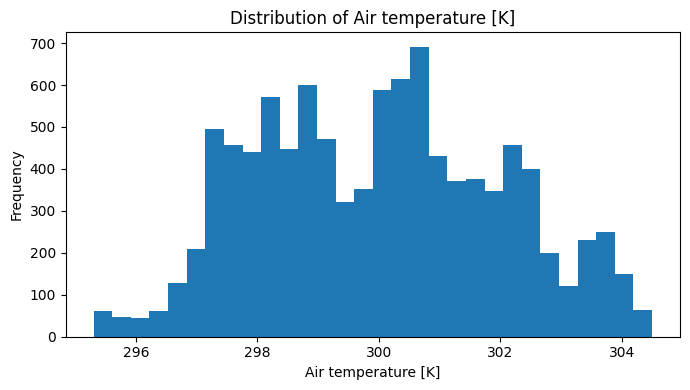

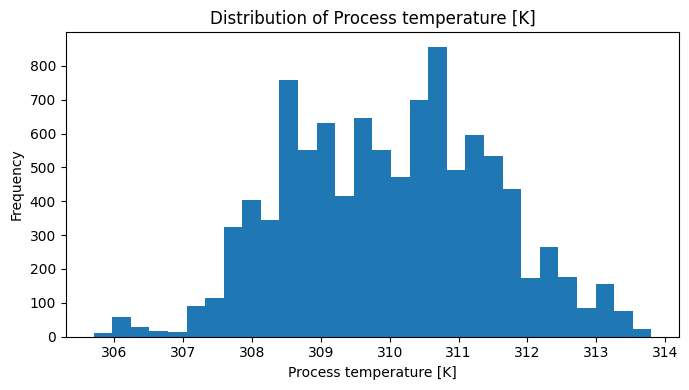

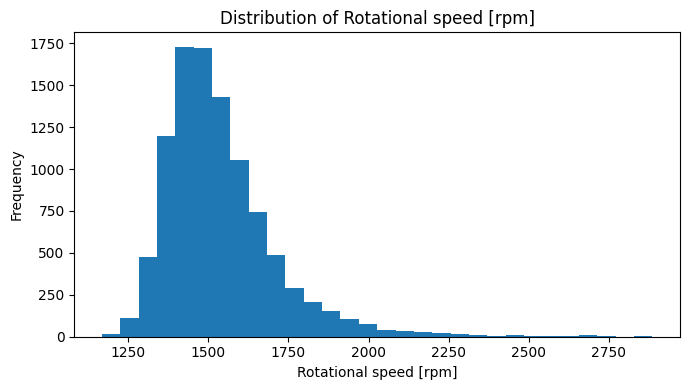

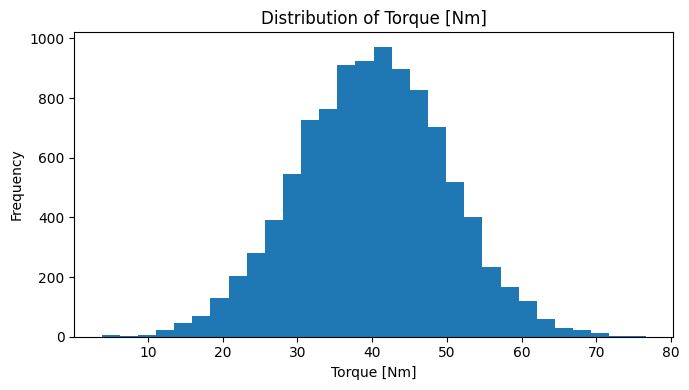

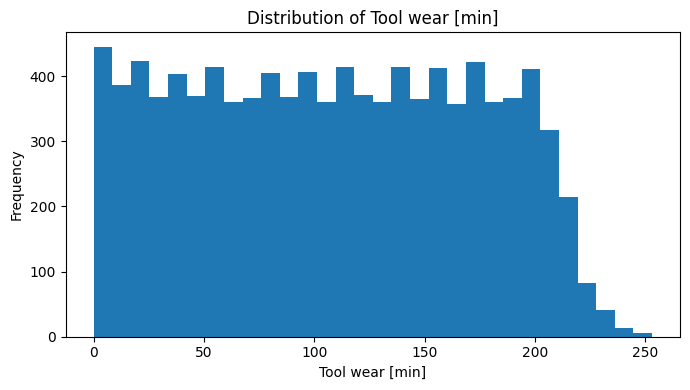

In [12]:
numeric_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column], bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


## 7. Machine Type Distribution

The dataset contains three machine types. Their distribution is shown below before converting the categorical variable into numerical form.


Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


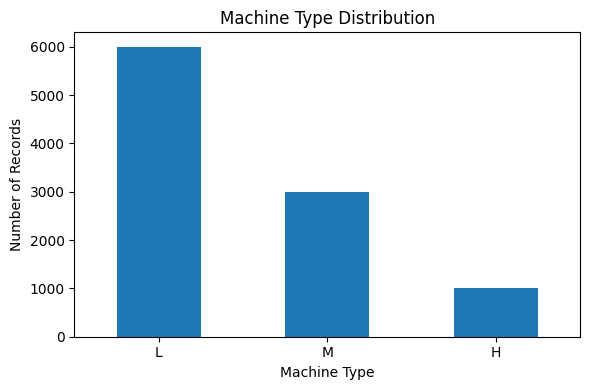

In [13]:
type_counts = df["Type"].value_counts()

print(type_counts)

plt.figure(figsize=(6, 4))
type_counts.plot(kind="bar")
plt.title("Machine Type Distribution")
plt.xlabel("Machine Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Machine Conditions and Failure

The relationship between several machine-condition variables and failure is explored using box plots. These plots help compare normal and failure cases.


<Figure size 700x400 with 0 Axes>

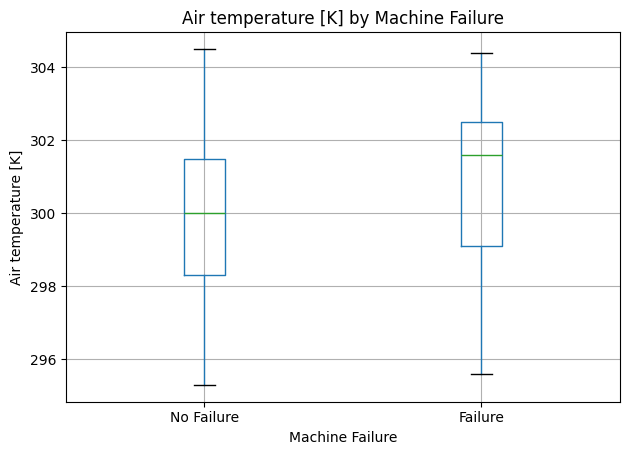

<Figure size 700x400 with 0 Axes>

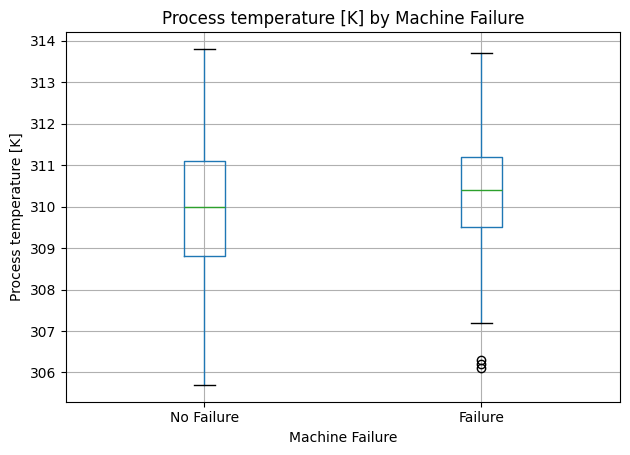

<Figure size 700x400 with 0 Axes>

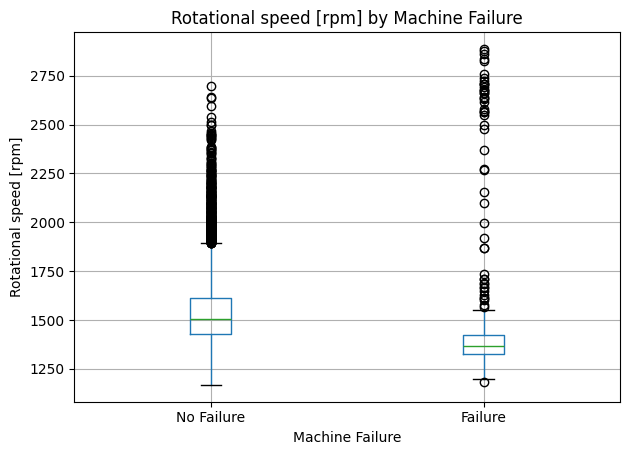

<Figure size 700x400 with 0 Axes>

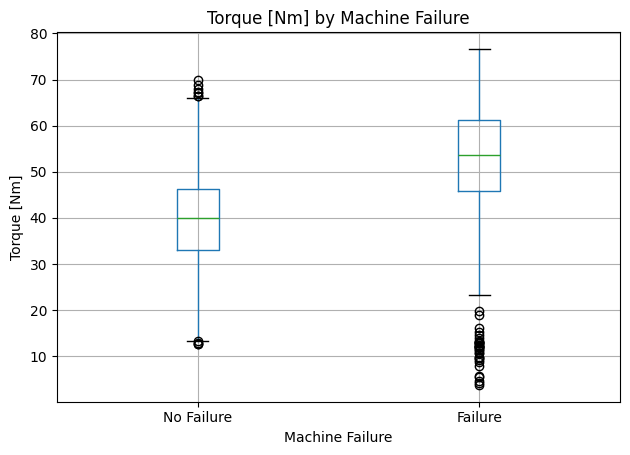

<Figure size 700x400 with 0 Axes>

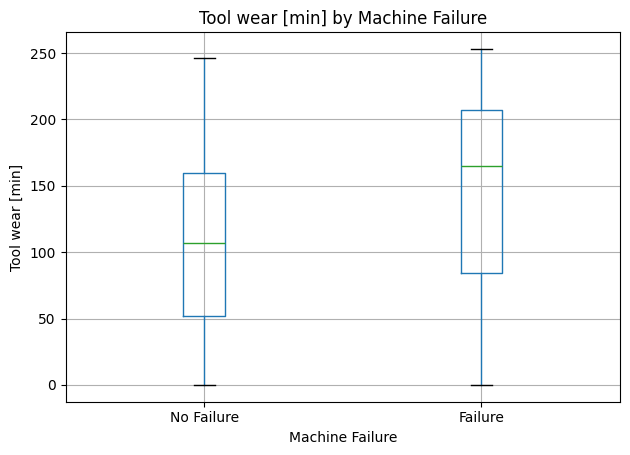

In [14]:
plot_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for column in plot_columns:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=column, by="Machine failure")
    plt.title(f"{column} by Machine Failure")
    plt.suptitle("")
    plt.xlabel("Machine Failure")
    plt.ylabel(column)
    plt.xticks([1, 2], ["No Failure", "Failure"])
    plt.tight_layout()
    plt.show()


## 9. Correlation Analysis

A correlation matrix is used to examine relationships between the numerical variables.

Correlation does not prove that one variable causes another, but it can help identify patterns in the dataset.


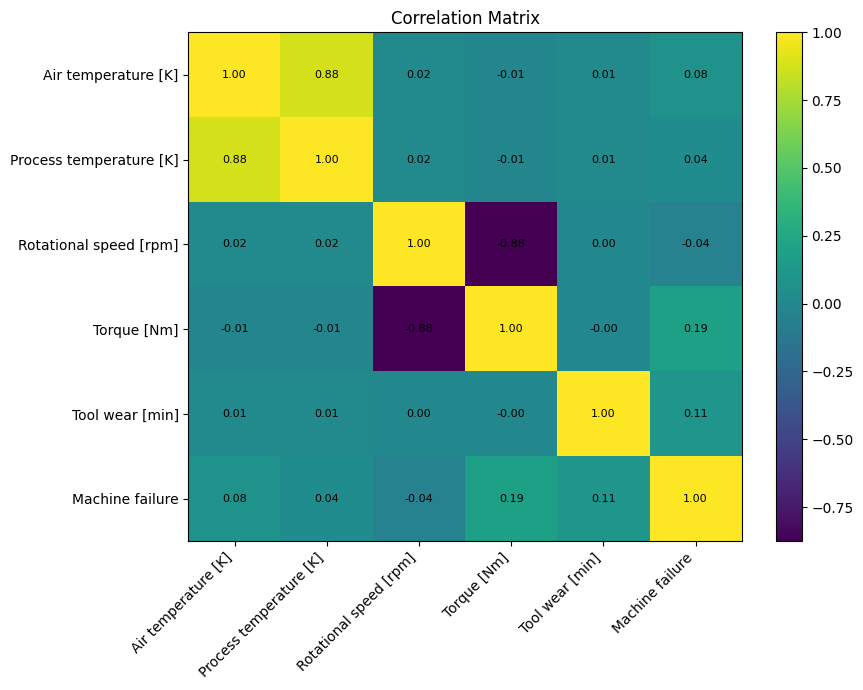

In [15]:
corr = df[numeric_columns + ["Machine failure"]].corr()

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


## 10. Data Preparation

Some columns in the original dataset are identifiers rather than useful machine-condition measurements.

The identifier columns are removed, and the machine type is converted into numerical form using one-hot encoding. The remaining columns are used as model features.


In [16]:
data = df.drop(columns=["UDI"])

y = data["Machine failure"]
X = data.drop(columns=["Machine failure"])

X = X.drop(columns=["Product ID"])
X = pd.get_dummies(X, columns=["Type"], drop_first=True)

print("Prepared feature shape:", X.shape)
display(X.head())


Prepared feature shape: (10000, 12)


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,True,False


## 11. Train-Test Split

The data is divided into training and testing sets. The model learns from the training data and is evaluated on data that it has not seen during training.

Stratification is used so that the distribution of machine failures remains similar in both sets.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 8000
Testing samples: 2000


## 12. Feature Scaling

The numerical features have different ranges, so standardization is applied before training the model.

The scaler is fitted only on the training data and then used to transform both training and testing data.


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")


Feature scaling completed.


## 13. Machine Learning Model

A **Random Forest Classifier** is used for this project.

Random Forest combines multiple decision trees and uses their combined predictions to classify each observation. It can capture non-linear relationships between machine operating conditions and failure.


In [19]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully.")


Random Forest model trained successfully.


## 14. Model Evaluation

The trained model is evaluated using accuracy, precision, recall, and F1-score.

For predictive maintenance, recall is especially important because failing to identify an actual machine failure can be more serious than incorrectly flagging a normal condition.


In [20]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["No Failure", "Failure"],
    zero_division=0
))


Accuracy : 0.9985
Precision: 1.0000
Recall   : 0.9559
F1-score : 0.9774

Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00      1932
     Failure       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



## 15. Confusion Matrix

The confusion matrix shows how many normal and failure cases were classified correctly or incorrectly.

It provides more detail than accuracy alone and helps identify whether the model is missing actual failure cases.


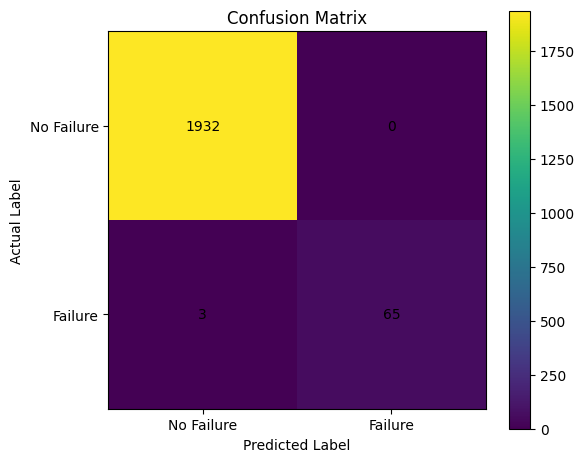

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["No Failure", "Failure"])
plt.yticks([0, 1], ["No Failure", "Failure"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


## 16. Feature Importance

Random Forest provides feature importance values that show which input variables were most useful to the trained model.

Feature importance should not be interpreted as proof that an individual variable directly causes machine failure.


Top features:


,Importance
Rotational speed [rpm],0.186626
Torque [Nm],0.180015
PWF,0.137016
HDF,0.110318
Tool wear [min],0.107480
OSF,0.105920
TWF,0.101438
Air temperature [K],0.040034
Process temperature [K],0.023406
Type_L,0.003908


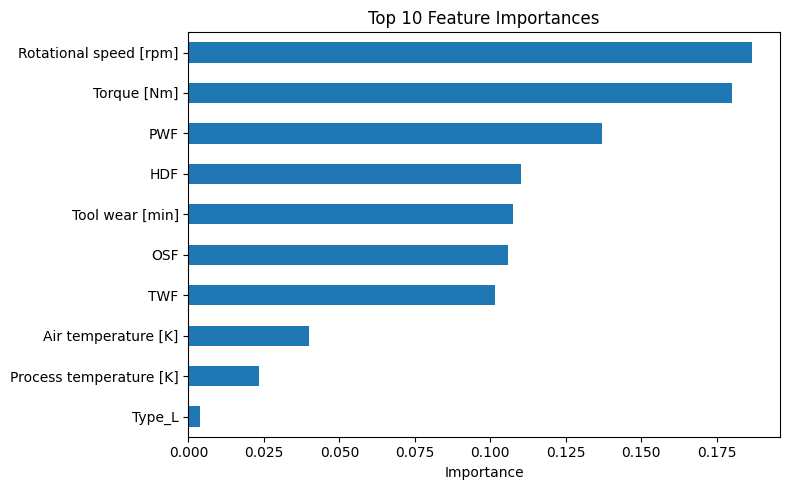

In [22]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top features:")
display(feature_importance.head(10).to_frame("Importance"))

plt.figure(figsize=(8, 5))
feature_importance.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 17. Example Predictions

A few test samples are displayed with their actual and predicted labels. This gives a simple example of how the trained model classifies machine-condition records.


In [23]:
sample_results = X_test.copy()
sample_results["Actual Failure"] = y_test.values
sample_results["Predicted Failure"] = y_pred

display(sample_results.head(10))


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Type_L,Type_M,Actual Failure,Predicted Failure
2997,300.5,309.8,1345,62.7,153,0,0,0,0,0,True,False,0,0
4871,303.7,312.4,1513,40.1,135,0,0,0,0,0,True,False,0,0
3858,302.5,311.4,1559,37.6,209,0,0,0,0,0,True,False,0,0
951,295.6,306.3,1509,35.8,60,0,0,0,0,0,False,False,0,0
6463,300.5,310.0,1358,60.4,102,0,0,0,0,0,False,False,0,0
3264,301.3,310.1,1455,44.1,188,0,0,0,0,0,False,False,0,0
4508,302.4,310.0,1426,46.6,102,0,0,0,0,0,True,False,0,0
2100,299.3,309.3,1471,46.0,42,0,0,0,0,0,False,True,0,0
7885,300.7,312.3,1590,36.3,93,0,0,0,0,0,True,False,0,0
2421,298.9,308.2,2384,15.0,19,0,0,0,0,0,True,False,0,0


## 18. Model Performance Summary

The main evaluation measures are collected into one table for a clear summary of the model's performance.


In [24]:
metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

display(metrics)


,Metric,Score
0,Accuracy,0.998500
1,Precision,1.000000
2,Recall,0.955882
3,F1-score,0.977444


## 19. Conclusion

This project developed a machine learning model for predictive maintenance using machine operating data.

A Random Forest classifier was trained to predict whether a machine failure occurred based on features such as temperature, rotational speed, torque, and tool wear. The model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix.

The dataset was also explored through several visualizations to understand machine conditions and their relationship with failure. Feature importance was used to identify the variables that were most useful to the trained model.

Overall, the project demonstrates how machine learning can be applied to predictive maintenance and how condition data can support the early identification of possible machine failures.

**Note:** This project is intended for educational purposes. Predictions from the model should not be treated as a replacement for professional industrial maintenance procedures or safety systems.


## 20. References

1. UCI Machine Learning Repository. AI4I 2020 Predictive Maintenance Dataset.
   https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset

2. Scikit-learn Documentation. Machine learning algorithms and evaluation metrics.
   https://scikit-learn.org/

3. Pandas Documentation. Data analysis and data processing tools.
   https://pandas.pydata.org/

## 21. Project Summary

- **Problem:** Predict machine failure from operating conditions
- **Dataset:** AI4I 2020 Predictive Maintenance Dataset
- **Model:** Random Forest Classifier
- **Task:** Binary classification
- **Evaluation:** Accuracy, Precision, Recall, F1-score and Confusion Matrix
- **Analysis:** Data distributions, machine-condition comparisons, correlation analysis, feature importance and example predictions
